In [1]:
print("Hello Megha")

Hello Megha


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
confirmed = pd.read_csv("data/time_series_covid19_confirmed_global.csv")
deaths = pd.read_csv("data/time_series_covid19_deaths_global.csv")
recovered = pd.read_csv("data/time_series_covid19_recovered_global.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/time_series_covid19_confirmed_global.csv'

In [4]:
import os
os.listdir()

['.ipynb_checkpoints', 'Covid Project', 'covid_analysis.ipynb']

In [5]:
confirmed = pd.read_csv("Covid Project/data/time_series_covid19_confirmed_global.csv")
deaths = pd.read_csv("Covid Project/data/time_series_covid19_deaths_global.csv")
recovered = pd.read_csv("Covid Project/data/time_series_covid19_recovered_global.csv")

In [6]:
confirmed.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


In [7]:
confirmed.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


In [8]:
confirmed.shape

(289, 1147)

In [9]:
confirmed_melted = confirmed.melt(
    id_vars=['Province/State', 'Country/Region'],
    var_name='Date',
    value_name='Confirmed'
)

In [10]:
confirmed_melted.head()

,Province/State,Country/Region,Date,Confirmed
0,NaN,Afghanistan,Lat,33.93911
1,NaN,Albania,Lat,41.15330
2,NaN,Algeria,Lat,28.03390
3,NaN,Andorra,Lat,42.50630
4,NaN,Angola,Lat,-11.20270


In [11]:
deaths_melted = deaths.melt(
    id_vars=['Province/State', 'Country/Region'],
    var_name='Date',
    value_name='Deaths'
)

In [12]:
recovered_melted = recovered.melt(
    id_vars=['Province/State', 'Country/Region'],
    var_name='Date',
    value_name='Recovered'
)

In [13]:
deaths_melted.head()

,Province/State,Country/Region,Date,Deaths
0,NaN,Afghanistan,Lat,33.93911
1,NaN,Albania,Lat,41.15330
2,NaN,Algeria,Lat,28.03390
3,NaN,Andorra,Lat,42.50630
4,NaN,Angola,Lat,-11.20270


In [14]:
recovered_melted.head()

,Province/State,Country/Region,Date,Recovered
0,NaN,Afghanistan,Lat,33.93911
1,NaN,Albania,Lat,41.15330
2,NaN,Algeria,Lat,28.03390
3,NaN,Andorra,Lat,42.50630
4,NaN,Angola,Lat,-11.20270


In [15]:
df = confirmed_melted.merge(
    deaths_melted,
    on=['Province/State', 'Country/Region', 'Date']
)

In [16]:
df = df.merge(
    recovered_melted,
    on=['Province/State', 'Country/Region', 'Date']
)

In [18]:
df.head()

,Province/State,Country/Region,Date,Confirmed,Deaths,Recovered
0,NaN,Afghanistan,Lat,33.93911,33.93911,33.93911
1,NaN,Albania,Lat,41.15330,41.15330,41.15330
2,NaN,Algeria,Lat,28.03390,28.03390,28.03390
3,NaN,Andorra,Lat,42.50630,42.50630,42.50630
4,NaN,Angola,Lat,-11.20270,-11.20270,-11.20270


In [19]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\USER\AppData\Local\Temp\ipykernel_10784\2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


DateParseError: Unknown datetime string format, unable to parse: Lat, at position 0

In [20]:
confirmed = confirmed.drop(['Lat', 'Long'], axis=1)
deaths = deaths.drop(['Lat', 'Long'], axis=1)
recovered = recovered.drop(['Lat', 'Long'], axis=1)

In [21]:
confirmed_melted = confirmed.melt(
    id_vars=['Province/State', 'Country/Region'],
    var_name='Date',
    value_name='Confirmed'
)

deaths_melted = deaths.melt(
    id_vars=['Province/State', 'Country/Region'],
    var_name='Date',
    value_name='Deaths'
)

recovered_melted = recovered.melt(
    id_vars=['Province/State', 'Country/Region'],
    var_name='Date',
    value_name='Recovered'
)

In [22]:
df = confirmed_melted.merge(
    deaths_melted,
    on=['Province/State', 'Country/Region', 'Date']
)

df = df.merge(
    recovered_melted,
    on=['Province/State', 'Country/Region', 'Date']
)

In [23]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\USER\AppData\Local\Temp\ipykernel_10784\2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [24]:
df.head()


,Province/State,Country/Region,Date,Confirmed,Deaths,Recovered
0,NaN,Afghanistan,2020-01-22,0,0,0
1,NaN,Albania,2020-01-22,0,0,0
2,NaN,Algeria,2020-01-22,0,0,0
3,NaN,Andorra,2020-01-22,0,0,0
4,NaN,Angola,2020-01-22,0,0,0


In [25]:
world_data = df.groupby('Date')[['Confirmed','Deaths','Recovered']].sum()

In [26]:
world_data.head()

,Confirmed,Deaths,Recovered
Date,,,
2020-01-22,557,17,30
2020-01-23,655,18,32
2020-01-24,941,26,39
2020-01-25,1434,42,42
2020-01-26,2117,56,56


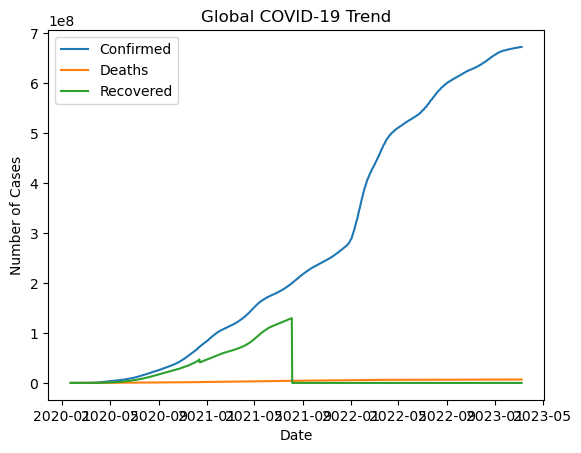

In [27]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(world_data.index, world_data['Confirmed'], label='Confirmed')
plt.plot(world_data.index, world_data['Deaths'], label='Deaths')
plt.plot(world_data.index, world_data['Recovered'], label='Recovered')

plt.legend()
plt.title('Global COVID-19 Trend')
plt.xlabel('Date')
plt.ylabel('Number of Cases')

plt.show()

In [28]:
latest = df[df['Date'] == df['Date'].max()]

In [29]:
country_data = latest.groupby('Country/Region')[['Confirmed','Deaths','Recovered']].sum()

In [30]:
top_countries = country_data.sort_values('Confirmed', ascending=False).head(10)
top_countries

,Confirmed,Deaths,Recovered
Country/Region,,,
US,103802702,1123836,0
India,44690738,530779,0
France,39866718,166176,0
Germany,38249060,168935,0
Brazil,37076053,699276,0
Japan,33320438,72997,0
"Korea, South",30615522,34093,0
Italy,25603510,188322,0
United Kingdom,24658705,220721,0


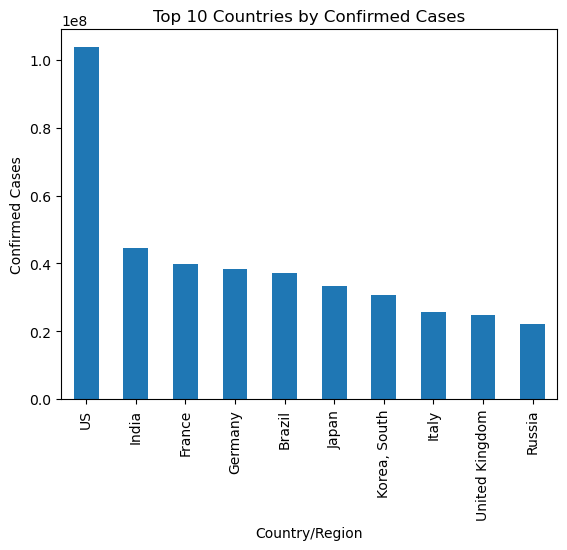

In [31]:
top_countries['Confirmed'].plot(kind='bar')
plt.title('Top 10 Countries by Confirmed Cases')
plt.ylabel('Confirmed Cases')
plt.show()